# Systemy uczące się - Zad. dom. 4: Ocena modeli predykcyjnych

### Autor rozwiązania
Uzupełnij poniższe informacje umieszczając swoje imię i nazwisko oraz numer indeksu:

In [785]:
NAME = "Jan Nowakowski"
ID = "155042"

Ten notebook zawiera zadania związane z oceną modeli predykcyjnych. Oprócz zadań programistycznych, notebook zawira również pytania, na które trzeba odpowiedzieć. Odpowiedzi nie muszą być długie, ale powinny być merytoryczne i odnosić się do omawianych zagadnień. W tym zadaniu domowym należy odpowiedzieć na WSZYSTKIE pytania.


## Format danych
W tym zadaniu domyślnym typem danych będą macierze (`np.ndarray`) o rozmiarze `(n, c)`, gdzie `n` to liczba obserwacji, a `c` to liczba klas. Wartości w macierzy będą reprezentować:

- w przypadku `y` - prawdziwe klasy (wartości binarne). Na przykład:
    ```
    [
        [1, 0, 0],
        [0, 0, 1],
        [1, 0, 0],
    ]
    ```
    oznacza, że pierwsza i trzecia obserwacja należą do klasy 0, a druga do klasy 2. 

- w przypadku `y_hat` - predykcje modelu. Wartości w macierzy mogą reprezentować:
    * prawdopodobieństwa przynależności do danej klasy (wartości z przedziału `[0, 1]`). Na przykład:
        ```
        [
            [0.9, 0.1, 0.0],
            [0.1, 0.2, 0.7],
            [0.8, 0.2, 0.0],
        ]
        ```
        oznacza, że model przewiduje, że pierwsza obserwacja należy do klasy 0 z prawdopodobieństwem 0.9, a do klasy 1 z prawdopodobieństwem 0.1.
    
    * predykcje (wartości binarne), gdzie wartość `1` oznacza przynależność do danej klasy, a wartość `0` jej brak.
        ```
        [
            [0, 1, 0],
            [0, 0, 1],
            [0, 1, 0],
        ]
        ```
        oznacza, że model przewiduje, że pierwsza obserwacja należy do klasy 1, a druga do klasy 2.

# Zadanie 1: Punktowe miary oceny klasyfikatorów

Zadanie polega na zaimplementowaniu funkcji obliczających punktowe miary oceny klasyfikatorów, takich jak:
- dokładność (accuracy),
- precyzja (precision),
- czułość (recall),
- specyficzność (specificity),
- F1,
- G-mean,
- balanced accuracy.

Uwagi:
- Do rozwiązania zadania można wykorzystać wyłącznie bibliotekę `numpy`.
- Na potrzeby zadania domowego można założyć, że klasyfikacja jest wieloklasowa, ale jednoetykietowa (tj. każda obserwacja należy do dokładnie jednej klasy).
- W przypadku, gdy mianownik w równaniu miary oceny jest równy 0, wartość miary powinna wynosić 0.
- Podpowiedź: przy obliczaniu wielu miar warto zaimplementować funkcję pomocniczą, która oblicza macierz pomyłek.

In [786]:
from typing import Literal

import numpy as np

In [787]:
y = np.eye(2, dtype=int)[np.repeat([0, 1], 50)]
y_hat_0 = np.tile([1, 0], (100, 1))
y_hat_1 = np.tile([0, 1], (100, 1))

In [788]:
def accuracy(y_hat: np.ndarray, y: np.ndarray) -> float:
    pred=np.argmax(y_hat, axis=1)
    truth=np.argmax(y, axis=1)
    return np.mean(pred==truth)
    

In [789]:
def _get_tp_fp_fn_tn(y_hat: np.ndarray, y: np.ndarray):
    """Funkcja pomocnicza obliczająca TP, FP, FN i TN dla każdej z klas."""
    preds = np.argmax(y_hat, axis=1)
    trues = np.argmax(y, axis=1)
    num_classes = y.shape[1]
    
    TP = np.zeros(num_classes)
    FP = np.zeros(num_classes)
    FN = np.zeros(num_classes)
    TN = np.zeros(num_classes)
    
    for c in range(num_classes):
        truth_c = (trues == c)
        pred_c = (preds == c)
        
        TP[c] = np.sum(truth_c & pred_c)
        FP[c] = np.sum((~truth_c) & pred_c)
        FN[c] = np.sum(truth_c & (~pred_c))
        TN[c] = np.sum((~truth_c) & (~pred_c))
        
    return TP, FP, FN, TN

In [790]:
def precision(y_hat: np.ndarray, y: np.ndarray, average: Literal["micro", "macro"] = "micro") -> float:
    """Funkcja obliczająca precyzję klasyfikacji (precision). Funkcja powinna wspierać klasyfikację wieloklasową.
    
    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`. 
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`. 
        average ("micro" | "macro"): Typ uśredniania wyników. Domyślnie "micro".
        
    Returns:
        float: Precyzja klasyfikacji.
    """
    TP, FP, FN, TN = _get_tp_fp_fn_tn(y_hat, y)
    
    if average == "micro": 
        if np.sum(TP) + np.sum(FP) > 0:
            return np.sum(TP) / (np.sum(TP) + np.sum(FP))
            
        else:
            return 0.0
    elif average == "macro":
        denominator = TP + FP
        prec_per_class = np.divide(TP, denominator, out=np.zeros_like(TP), where=(denominator != 0))
        return float(np.mean(prec_per_class))
        


In [791]:
def recall(y_hat: np.ndarray, y: np.ndarray, average: Literal["micro", "macro"] = "micro") -> float:
    """Funkcja obliczająca czułość klasyfikacji (recall). Funkcja powinna wspierać klasyfikację wieloklasową.
    
    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`. 
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`. 
        average ("micro" | "macro"): Typ uśredniania wyników. Domyślnie "micro".
        
    Returns:
        float: Precyzja klasyfikacji.
    """
    TP, FP, FN, TN = _get_tp_fp_fn_tn(y_hat, y)
    
    if average == "micro": 
        if np.sum(TP) + np.sum(FN) > 0:
            return np.sum(TP) / (np.sum(TP) + np.sum(FN))
        else:
            return 0.0
    elif average == "macro":
        denominator = TP + FN
        recall_per_class = np.divide(TP, denominator, out=np.zeros_like(TP), where=(denominator != 0))
        return float(np.mean(recall_per_class))

In [792]:
def specificity(y_hat: np.ndarray, y: np.ndarray, average: Literal["micro", "macro"] = "micro") -> float:
    """Funkcja obliczająca specyficzność klasyfikacji (specificity). Funkcja powinna wspierać klasyfikację wieloklasową.
    
    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`. 
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`. 
        average ("micro" | "macro"): Typ uśredniania wyników. Domyślnie "micro".
        
    Returns:
        float: Specyficzność klasyfikacji.
    """
    TP, FP, FN, TN = _get_tp_fp_fn_tn(y_hat, y)
    
    if average == "micro": 
        if np.sum(TN) + np.sum(FP) > 0:
            return np.sum(TN) / (np.sum(TN) + np.sum(FP))
        else:
            return 0.0
    elif average == "macro":
        denominator = TN + FP
        specificity_per_class = np.divide(TN, denominator, out=np.zeros_like(TN), where=(denominator != 0))
        return float(np.mean(specificity_per_class))

Zatrzymaj się w tym miejscu na chwilę i poeksperymentuj z dotychczas zaimplementowanymi funkcjami i danymi testowymi. Spróbuj zrozumieć, jak działają poszczególne miary oceny klasyfikatorów. Możesz ograniczyć się do uśredniania wyników "micro".

In [793]:
print("Dokładność klasyfikacji dla y_hat_0:", accuracy(y_hat_0, y))
print("Dokładność klasyfikacji dla y_hat_1:", accuracy(y_hat_1, y))
print("Precyzja klasyfikacji dla y_hat_0:", precision(y_hat_0, y,"macro"))
print("Precyzja klasyfikacji dla y_hat_1:", precision(y_hat_1, y,"macro"))
print("Czułość klasyfikacji dla y_hat_0:", recall(y_hat_0, y,"macro"))
print("Czułość klasyfikacji dla y_hat_1:", recall(y_hat_1, y,"macro"))
print("Specyficzność klasyfikacji dla y_hat_0:", specificity(y_hat_0, y,"macro"))
print("Specyficzność klasyfikacji dla y_hat_1:", specificity(y_hat_1, y,"macro"))

Dokładność klasyfikacji dla y_hat_0: 0.5
Dokładność klasyfikacji dla y_hat_1: 0.5
Precyzja klasyfikacji dla y_hat_0: 0.25
Precyzja klasyfikacji dla y_hat_1: 0.25
Czułość klasyfikacji dla y_hat_0: 0.5
Czułość klasyfikacji dla y_hat_1: 0.5
Specyficzność klasyfikacji dla y_hat_0: 0.5
Specyficzność klasyfikacji dla y_hat_1: 0.5


Odpowiedz na pytanie

1. Czy zaimplementowane funkcje mogą być wystarczające do oceny modeli klasyfikacyjnych? Jeśli nie, to dlaczego? Jeśli tak, to w jakich przypadkach?

Zaimplementowane funkcje nie są wystarczające do oceny modeli zwłaszcza w wersji mikro, zdominowana może zostać wtedy mniejsza klasa. Nie uwzgledniają one też pewności odpowiedzi modelu, bo operujemy na binarnych klasyfikacjach ale w przypadku prawdopodobieństw i użycia argmax utracilibyśmy część informacji. Klasyfikator strzelający w ciemno jedną klasę osiąga 50% w micro podejściu na każdym wskaźniku, a jest bezużyteczny oraz trudno jest porównać klasyfikator który miałby 100% precision i 50% recall z tym który ma np 75% na obydwu wskaznikach.


In [794]:
def f1(y_hat: np.ndarray, y: np.ndarray, average: Literal["micro", "macro"] = "micro") -> float:
    """Funkcja obliczająca miarę F1. Funkcja powinna wspierać klasyfikację wieloklasową.
    
    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`. 
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`. 
        average ("micro" | "macro"): Typ uśredniania wyników. Domyślnie "micro".
        
    Returns:
        float: Specyficzność klasyfikacji.
    """
    TP, FP, FN, TN = _get_tp_fp_fn_tn(y_hat, y)
    
    if average == "micro":
        prec = precision(y_hat, y, "micro")
        rec = recall(y_hat, y, "micro")
        if prec + rec > 0:
            return float(2 * (prec * rec) / (prec + rec))
        else:
            return 0.0
    elif average == "macro":
        denominator_p = TP + FP
        prec_per_class = np.divide(TP, denominator_p, out=np.zeros_like(TP), where=(denominator_p != 0))
        
        denominator_r = TP + FN
        rec_per_class = np.divide(TP, denominator_r, out=np.zeros_like(TP), where=(denominator_r != 0))
        
        denominator_f1 = prec_per_class + rec_per_class
        f1_per_class = np.divide(2 * prec_per_class * rec_per_class, denominator_f1, out=np.zeros_like(TP), where=(denominator_f1 != 0))
        return float(np.mean(f1_per_class))

In [795]:
def g_mean(y_hat: np.ndarray, y: np.ndarray) -> float:
    """Funkcja obliczająca miarę G-mean. Funkcja powinna wspierać klasyfikację wieloklasową.
    
    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`. 
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`. 
        
    Returns:
        float: Specyficzność klasyfikacji.
    """
    TP, FP, FN, TN = _get_tp_fp_fn_tn(y_hat, y)
    denominator = TP + FN
    rec_per_class = np.divide(TP, denominator, out=np.zeros_like(TP), where=(denominator != 0))
    return float(np.power(np.prod(rec_per_class), 1.0 / len(rec_per_class)))

In [796]:
def balanced_accuracy(y_hat: np.ndarray, y: np.ndarray) -> float:
    """Funkcja obliczająca zbalansowaną dokładność klasyfikacji. Funkcja powinna wspierać klasyfikację wieloklasową.
    
    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`. 
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`. 
        
    Returns:
        float: Zbalansowana dokładność klasyfikacji.
    """
    return recall(y_hat, y, average="macro")

In [797]:
print("f1 dla y_hat_0:",f1(y_hat_0, y, average="macro"))
print("f1 dla y_hat_1:",f1(y_hat_1, y, average="macro"))
print("g_mean dla y_hat_0:",g_mean(y_hat_0, y))
print("g_mean dla y_hat_1:",g_mean(y_hat_1, y))
print("balanced_accuracy dla y_hat_0:",balanced_accuracy(y_hat_0, y))
print("balanced_accuracy dla y_hat_1:",balanced_accuracy(y_hat_1, y))

f1 dla y_hat_0: 0.3333333333333333
f1 dla y_hat_1: 0.3333333333333333
g_mean dla y_hat_0: 0.0
g_mean dla y_hat_1: 0.0
balanced_accuracy dla y_hat_0: 0.5
balanced_accuracy dla y_hat_1: 0.5


Sprawdź jak zaimplementowane funkcje działają na 3 zbiorach testowych o różnej charakterystyce.

### Scenariusz 1

In [798]:
# dane silnie niezbalansowane: 80% klasa 0, 10% klasa 1, 5% klasa 2, 5% klasa 3
y = np.eye(4)[np.array([0] * 80 + [1] * 10 + [2] * 5 + [3] * 5)]

# model przewiduje zawsze klasę 0
y_hat_all_0 = np.eye(4)[np.array([0] * 100)]

# model poprawnie przewiduje klasy 0 i 1, ale zawsze myli klasy 2 i 3
y_hat_partial = np.eye(4)[np.array([0] * 80 + [1] * 10 + [3] * 5 + [2] * 5)]

In [799]:

print(f"Accuracy: {accuracy(y_hat_all_0, y):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy(y_hat_all_0, y):.4f}")
print(f"G-mean: {g_mean(y_hat_all_0, y):.4f}")
print(f"F1 (macro): {f1(y_hat_all_0, y, 'macro'):.4f}")
print("Dokładność klasyfikacji dla y_hat_0:", accuracy(y_hat_all_0, y))
print("Precyzja klasyfikacji dla y_hat_0:", precision(y_hat_all_0, y,"macro"))
print("Czułość klasyfikacji dla y_hat_0:", recall(y_hat_all_0, y,"macro"))
print("Specyficzność klasyfikacji dla y_hat_0:", specificity(y_hat_all_0, y,"macro"))
print("\n")
print(f"Accuracy: {accuracy(y_hat_partial, y):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy(y_hat_partial, y):.4f}")
print(f"G-mean: {g_mean(y_hat_partial, y):.4f}")
print(f"F1 (macro): {f1(y_hat_partial, y, 'macro'):.4f}")
print("Dokładność klasyfikacji dla y_hat_0:", accuracy(y_hat_partial, y))
print("Precyzja klasyfikacji dla y_hat_0:", precision(y_hat_partial, y,"macro"))
print("Czułość klasyfikacji dla y_hat_0:", recall(y_hat_partial, y,"macro"))
print("Specyficzność klasyfikacji dla y_hat_0:", specificity(y_hat_partial, y,"macro"))


Accuracy: 0.8000
Balanced Accuracy: 0.2500
G-mean: 0.0000
F1 (macro): 0.2222
Dokładność klasyfikacji dla y_hat_0: 0.8
Precyzja klasyfikacji dla y_hat_0: 0.2
Czułość klasyfikacji dla y_hat_0: 0.25
Specyficzność klasyfikacji dla y_hat_0: 0.75


Accuracy: 0.9000
Balanced Accuracy: 0.5000
G-mean: 0.0000
F1 (macro): 0.5000
Dokładność klasyfikacji dla y_hat_0: 0.9
Precyzja klasyfikacji dla y_hat_0: 0.5
Czułość klasyfikacji dla y_hat_0: 0.5
Specyficzność klasyfikacji dla y_hat_0: 0.9736842105263157


### Scenariusz 2

In [800]:
# dane niezbalansowane: 50 próbek klasy 0, 25 klasy 1, 15 klasy 2, 10 klasy 3
y = np.eye(4)[np.array([0] * 50 + [1] * 25 + [2] * 15 + [3] * 10)]

# Model przewiduje 60 próbek jako klasa 0, reszta losowo
np.random.seed(42)
y_hat = np.eye(4)[np.array([0] * 60 + list(np.random.choice([1, 2, 3], size=40)))]

In [801]:
print(f"Accuracy: {accuracy(y_hat, y):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy(y_hat, y):.4f}")
print(f"G-mean: {g_mean(y_hat, y):.4f}")
print(f"F1 (macro): {f1(y_hat, y, 'macro'):.4f}")
print(f"Precision (macro): {precision(y_hat, y, 'macro'):.4f}")
print("Dokładność klasyfikacji dla y_hat_0:", accuracy(y_hat, y))
print("Precyzja klasyfikacji dla y_hat_0:", precision(y_hat, y,"macro"))
print("Czułość klasyfikacji dla y_hat_0:", recall(y_hat, y,"macro"))
print("Specyficzność klasyfikacji dla y_hat_0:", specificity(y_hat, y,"macro"))


Accuracy: 0.6500
Balanced Accuracy: 0.5150
G-mean: 0.4229
F1 (macro): 0.4865
Precision (macro): 0.4978
Dokładność klasyfikacji dla y_hat_0: 0.65
Precyzja klasyfikacji dla y_hat_0: 0.49777183600713015
Czułość klasyfikacji dla y_hat_0: 0.515
Specyficzność klasyfikacji dla y_hat_0: 0.8756862745098039


### Scenariusz 3

In [802]:
# dane niezbalansowane jak w Scenariuszu 2
y = np.eye(4)[np.array([0] * 50 + [1] * 25 + [2] * 15 + [3] * 10)]

# model losowy
np.random.seed(0)
y_hat = np.eye(4)[np.random.choice([0, 1, 2, 3], size=100)]

In [803]:
print(f"Accuracy: {accuracy(y_hat, y):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy(y_hat, y):.4f}")
print(f"G-mean: {g_mean(y_hat, y):.4f}")
print(f"F1 (macro): {f1(y_hat, y, 'macro'):.4f}")

print(f"Recall (macro): {recall(y_hat, y, 'macro'):.4f}")
print("Dokładność klasyfikacji dla y_hat_0:", accuracy(y_hat, y))
print("Precyzja klasyfikacji dla y_hat_0:", precision(y_hat, y,"macro"))
print("Czułość klasyfikacji dla y_hat_0:", recall(y_hat, y,"macro"))
print("Specyficzność klasyfikacji dla y_hat_0:", specificity(y_hat, y,"macro"))


Accuracy: 0.2400
Balanced Accuracy: 0.2600
G-mean: 0.2489
F1 (macro): 0.2228
Recall (macro): 0.2600
Dokładność klasyfikacji dla y_hat_0: 0.24
Precyzja klasyfikacji dla y_hat_0: 0.24280701754385964
Czułość klasyfikacji dla y_hat_0: 0.26
Specyficzność klasyfikacji dla y_hat_0: 0.7468300653594773


### Pytania

Odpowiedz na pytania:
1. Jakie różnice daje uśrednianie wyników "micro" w porównaniu do "macro"? Dla jakich danych warto użyć jednego, a dla jakich drugiego sposobu uśredniania wyników?
2. Dlaczego warto stosować zbalansowaną dokładność (balanced accuracy) zamiast zwykłej dokładności (accuracy)? 
3. Dlaczego warto stosować miarę G-mean zamiast F1? Dla jakich scenariuszy miara G-mean pozwala na bardziej adekwatną ocenę modelu?

Uśrednianie micro oblicza miarę łącznie (sumuje wszystkie TP,TN,FP,FN). Przez to wynik jest zdominowany przez najliczniejsze klasy np. model ma 99TP i 1FP na jednej klasie a na drugiej 0 TP i 2FP, to w skali micro będzie miał precision bliskie 97%. Uśrednianie macro liczy miarę dla każdej klasy z osobna, a następnie wyciąga z nich średnią arytmetyczną – dzięki temu klasa licząca 5 próbek ma taką samą wagę jak klasa licząca 5000 próbek. Uśredniania micro warto używać dla zbiorów  zbalansowanych, natomiast macro w przypadku danych niezbalansowanych.

W przypadku danych niezblansowanych accuracy nie przekazuje prawie żadnej informacji, jeżeli mamy 100% na klasie dominującej i 0% na mniejszościowej to finalne accuracy jest dosyć wysokie, a model jest bezużyteczny. ballanced accuracy liczy średnią recall każdej klasy z osobna więc nie wykrywanie, którejkolwiek z klas mocno go obniży, nawet jeżeli dane są niezbalansowane

Metryka F1 opiera się o recall i precision klas i  uśrednia wyliczoną wartość pomiędzy klasami, sprawia to że ponownie nie wykrywanie jednej z klas może zostac zakryte poprzez dobre działanie dla innych. W g-mean natomiast jeżeli model pominie jakąkolwiek klasę, to przy mnożeniu recall=0 cała wartość wskaznika zostanie wyzerowana co widać w pierwszym scenariuszu, plus wytłumaczenie dla użytkownika modelu czym jest średnia harmoniczna może być trudne. 

# Zadanie 2: k-folds cross-validation

Zaimplementuj funkcję `split_to_k_folds`, która dokona podziału danych na `k` zbiorów treningowych i testowych. Następnie dokonaj analizy wpływu stratyfikacji na postrzegane ryzyko modelu.

In [804]:
def split_to_k_folds(x: np.ndarray, y: np.ndarray, k: int = 5, stratify: bool = True
                     ) -> list[tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]]:
    """Funkcja implementująca k-krotną walidację krzyżową.
    
    W przypadku stratyfikacji, funkcja powinna zachować proporcje klas w podziałach. W tym celu można 
    wykorzystać prosty algorytm zaproponowany podczas laboratorium.
    
    Funkcja powinna zwracać listę krotek, gdzie każda krotka zawiera dane podzielone na zbiór treningowy i testowy.
    Rozwiązanie to w oczywisty sposób nie jest optymalne pod względem pamięciowym, ale taki format zwracania danych
    pomoże w dalszej części zadania.
    
    Args:
        x (np.ndarray): Macierz z danymi o wymiarach `(n, d)`.
        y (np.ndarray): Macierz z etykietami o wymiarach `(n, c)`.
        k (int): Liczba podziałów zbioru danych. Domyślnie 5.
        stratify (bool): Czy zachować proporcje klas w podziałach. Domyślnie `True`.
    
    Returns:
        list[tuple[np.ndarray]]: Lista krotek z podziałami danych na zbiór treningowy i testowy.
    """
    n = x.shape[0]
    indices = np.arange(n)
    
    np.random.shuffle(indices)
    
    folds = [[] for _ in range(k)]
    
    if stratify:
        trues = np.argmax(y, axis=1) if y.ndim > 1 else y
        classes = np.unique(trues)
        
        for c in classes:
            c_indices = indices[trues[indices] == c]
            splits = np.array_split(c_indices, k)
            for i in range(k):
                folds[i].extend(splits[i])
    else:
        splits = np.array_split(indices, k)
        for i in range(k):
            folds[i].extend(splits[i])
            
    results = []
    for i in range(k):
        test_idx = np.array(folds[i], dtype=int)
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i]).astype(int)
        
        results.append((
            (x[train_idx], y[train_idx]),
            (x[test_idx], y[test_idx])
        ))
        
    return results

Przykładowe dane testowe. Zwróć uwagę, że dane te są niezbalansowane. Możesz dokonać modyfikacji danych, aby zobaczyć, jak zachowuje się algorytm w zależności od charakterystyki danych.

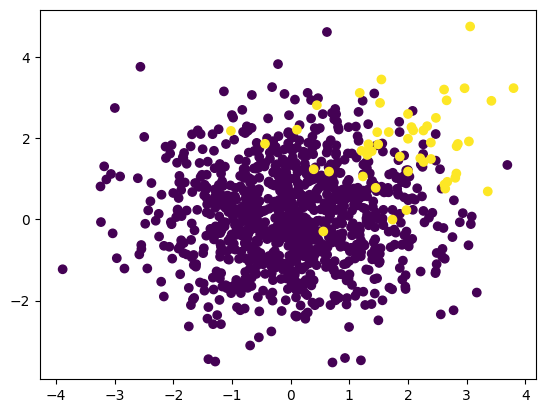

In [805]:
import matplotlib.pyplot as plt

n0 = 1000
n1 = 50

np.random.seed(42)
x1 = np.random.randn(n0, 2) * 1.2
x2 = np.random.randn(n1, 2) + [2, 2]

x = np.vstack([x1, x2])
y = np.array([0] * n0 + [1] * n1)

plt.scatter(x[:, 0], x[:, 1], c=y)
plt.show()

In [806]:
splits_stratified = split_to_k_folds(x, y, k=5, stratify=True)
splits = split_to_k_folds(x, y, k=5, stratify=False)

Przeprowadź walidację krzyżową dla klasyfikatora `GaussianNB` na danych z poprzedniego kroku. Porównaj wyniki dla obu wariantów podziału danych. Na podstawie obserwacji z poprzedniego zadania, wybierz miary oceny klasyfikatora, które uznasz za najbardziej adekwatne do tego zadania. 

Poniższą komórkę możesz dowolnie modyfikować, aby np. obliczać kilka miar jednocześnie. 

In [807]:
from sklearn.naive_bayes import GaussianNB

metrics = []
num_classes = 2 

for (x_train, y_train), (x_test, y_test) in splits_stratified: 
    model = GaussianNB()
    model.fit(x_train, y_train)
    y_hat = model.predict(x_test)
    
    y_test_ohe = np.eye(num_classes)[y_test.astype(int)]
    y_hat_ohe = np.eye(num_classes)[y_hat.astype(int)]
    
metrics.append(
        [balanced_accuracy(y_hat_ohe, y_test_ohe),
         g_mean(y_hat_ohe, y_test_ohe),
         f1(y_hat_ohe, y_test_ohe, average="macro")]
    )

metrics_array = np.array(metrics)

means = np.mean(metrics_array, axis=0)
stds = np.std(metrics_array, axis=0)

print(f"Balanced Accuracy: {means[0]: .4f} +/- {stds[0]: .4f}")
print(f"G-mean:            {means[1]: .4f} +/- {stds[1]: .4f}")
print(f"F1 (macro):        {means[2]: .4f} +/- {stds[2]: .4f}")

Balanced Accuracy:  0.6975 +/-  0.0000
G-mean:             0.6309 +/-  0.0000
F1 (macro):         0.7580 +/-  0.0000


### Pytania

Odpowiedz na pytania:
1. Jaka była Twoja motywacja do wybrania konkretnych miar klasyfikacji?
2. Dla jakich danych warto zastosować stratyfikację podczas walidacji krzyżowej?
3. Jakie ryzyko niesie za sobą losowy podział danych na dwa zbiory (treningowy i testowy), zamiast używania walidacji krzyżowej ze stratyfikacją?



1. Są to miary najbardziej ogólne i pozwalające zobrazowac działanie całego modelu nawet w przypadku niezbilansowanych danych, na których działa model, zwykłe accuracy dla modelu zawsze 0 miałoby bardzo wysoki wynik tak samo precision i recall micro, a f1 i g_mean przedstawiają informację o obu klasach w rownorzędny sposób
2. Warto zastosować stratyfikację dla danych w której jedna klasa występuje stosunkowo rzadko, aby zachować proporcje pomiędzy klasami oraz uniknąć bloków wogóle nie zawierających danej klasy, oraz w przypadku małych zbiorów danych
3. Losowy podział ma ryzyko nie wrzucenia klasy rzadko występującej do zbioru treningowego przez co model nie nauczy się jej wykrywania. Działa on dobrze dopiero dla ogromnych zestawów danych (powyżej 10000), przy mniejszych losowość podziału może mieć wpływ na finalny wynik modelu.